In [217]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\User\PyCharmMiscProject\Datasets\student_placement_synthetic.csv')
print(df.columns)
print(df.shape)


Index(['branch', 'college_tier', 'cgpa', 'backlogs', 'coding_skills',
       'dsa_score', 'aptitude_score', 'communication_skills', 'ml_knowledge',
       'system_design', 'internships', 'projects_count', 'certifications',
       'hackathons', 'open_source_contributions', 'extracurriculars',
       'placement_status', 'salary_package_lpa'],
      dtype='object')
(100000, 18)


In [272]:
print(df.dtypes)

branch                         int64
college_tier                   int64
cgpa                         float64
backlogs                       int64
coding_skills                float64
dsa_score                    float64
aptitude_score               float64
communication_skills         float64
ml_knowledge                 float64
system_design                float64
internships                    int64
projects_count                 int64
certifications                 int64
hackathons                     int64
open_source_contributions      int64
extracurriculars               int64
placement_status               int64
salary_package_lpa           float64
dtype: object


In [219]:
df.isna().sum()

branch                           0
college_tier                     0
cgpa                             0
backlogs                         0
coding_skills                    0
dsa_score                        0
aptitude_score                   0
communication_skills             0
ml_knowledge                     0
system_design                    0
internships                      0
projects_count                   0
certifications                   0
hackathons                       0
open_source_contributions        0
extracurriculars                 0
placement_status                 0
salary_package_lpa           31525
dtype: int64

<Axes: xlabel='placement_status', ylabel='count'>

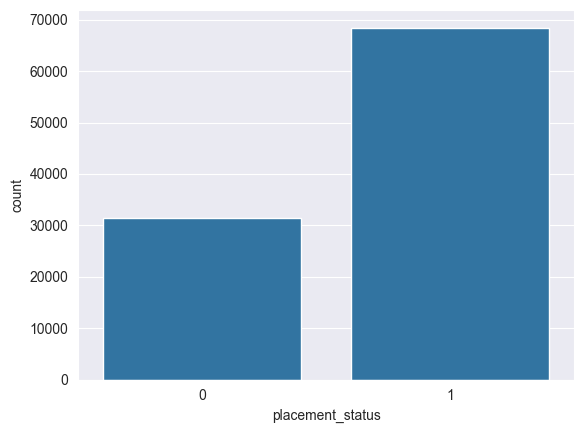

In [220]:
sns.countplot(x=df["placement_status"])# unbalance dataset

<Axes: xlabel='placement_status', ylabel='cgpa'>

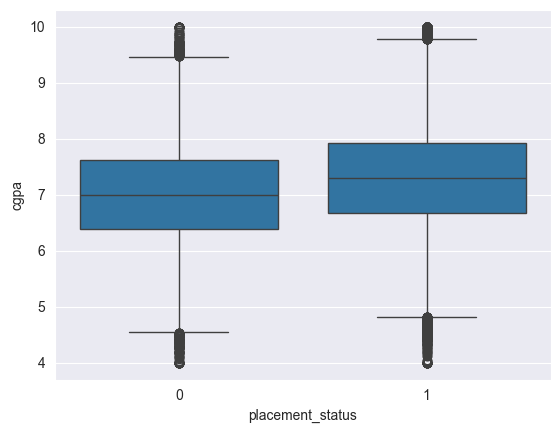

In [221]:
sns.boxplot(x="placement_status", y="cgpa", data=df)

<Axes: xlabel='placement_status', ylabel='internships'>

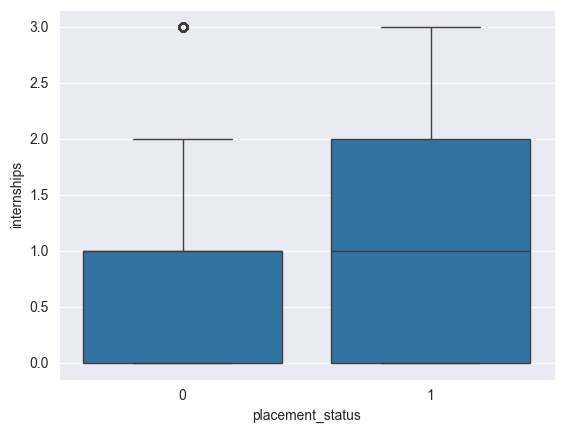

In [222]:
sns.boxplot(x="placement_status", y="internships", data=df)

<Axes: xlabel='placement_status', ylabel='coding_skills'>

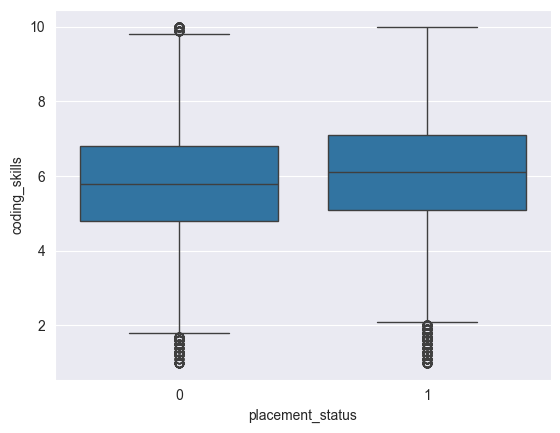

In [223]:
sns.boxplot(x="placement_status", y="coding_skills", data=df)

In [224]:
df

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,IT,Tier-3,6.08,0,3.1,5.4,67.4,4.3,9.1,3.8,2,3,2,0,0,3,0,NaN
99996,IT,Tier-3,7.46,0,4.8,6.8,59.5,7.6,5.6,2.4,1,2,3,0,1,0,1,16.58
99997,EE,Tier-2,7.94,0,4.9,9.1,55.1,6.1,3.5,5.2,0,2,1,0,1,2,1,17.24
99998,ME,Tier-3,6.63,0,5.0,8.0,65.0,5.7,6.2,0.2,1,4,2,0,0,1,1,17.01


In [225]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.columns:
    if df[col].dtypes == "object":
        df[col] = le.fit_transform(df[col])


In [226]:
x = df.drop(["placement_status", "salary_package_lpa"], axis=1)
x

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars
0,3,2,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1
1,2,1,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0
2,4,1,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0
3,0,1,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0
4,1,1,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,5,2,6.08,0,3.1,5.4,67.4,4.3,9.1,3.8,2,3,2,0,0,3
99996,5,2,7.46,0,4.8,6.8,59.5,7.6,5.6,2.4,1,2,3,0,1,0
99997,4,1,7.94,0,4.9,9.1,55.1,6.1,3.5,5.2,0,2,1,0,1,2
99998,6,2,6.63,0,5.0,8.0,65.0,5.7,6.2,0.2,1,4,2,0,0,1


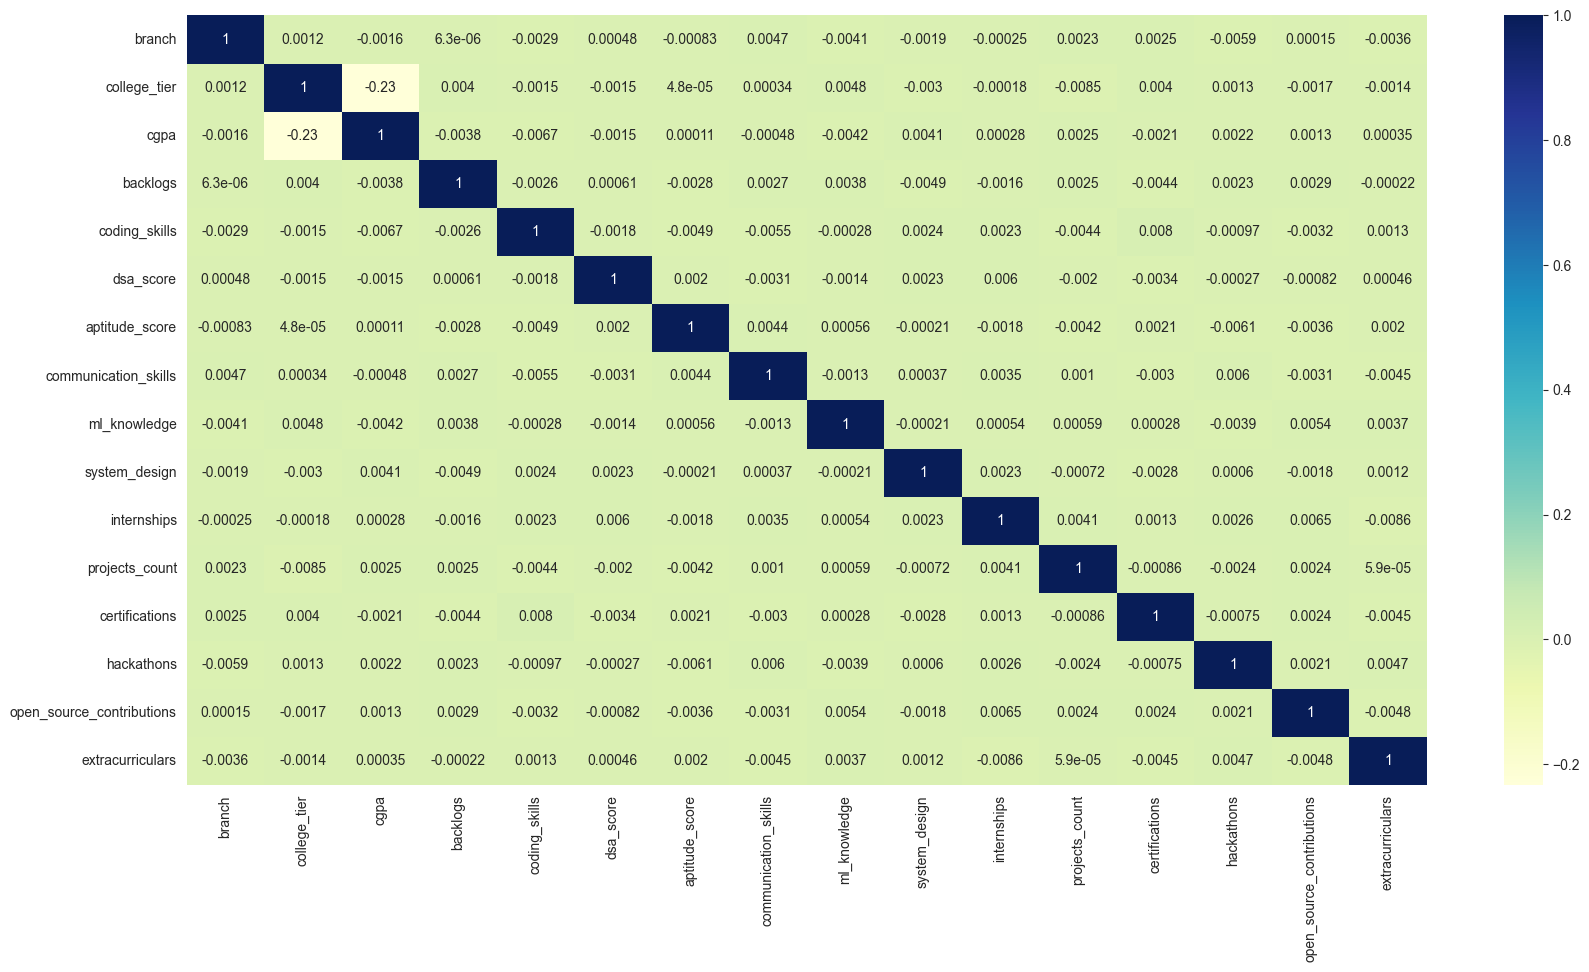

In [227]:
plt.figure(figsize = (20, 10))
sns.heatmap(x.corr(), annot=True, cmap="YlGnBu")
plt.show()

In [228]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["features"] = x.columns
vif_data["vif"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]
vif_data.sort_values(by="vif", ascending=False, inplace=True)
vif_data


,features,vif
2,cgpa,37.619747
6,aptitude_score,25.117779
7,communication_skills,15.420088
4,coding_skills,15.353275
5,dsa_score,9.930017
8,ml_knowledge,6.051708
9,system_design,5.904003
11,projects_count,4.613150
1,college_tier,4.207098
0,branch,3.153675


In [229]:
x.drop(["cgpa"], axis=1, inplace=True)

In [230]:
vif_data = pd.DataFrame()
vif_data["features"] = x.columns
vif_data["vif"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]
vif_data.sort_values(by="vif", ascending=False, inplace=True)
vif_data

,features,vif
5,aptitude_score,21.250254
6,communication_skills,14.245837
3,coding_skills,14.189269
4,dsa_score,9.500662
7,ml_knowledge,5.915355
8,system_design,5.766411
10,projects_count,4.532912
1,college_tier,4.190541
0,branch,3.123676
11,certifications,2.762486


In [231]:
x.drop(["aptitude_score"], axis=1, inplace=True)

In [232]:
vif_data = pd.DataFrame()
vif_data["features"] = x.columns
vif_data["vif"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]
vif_data.sort_values(by="vif", ascending=False, inplace=True)
vif_data

,features,vif
3,coding_skills,13.011055
5,communication_skills,13.002504
4,dsa_score,9.047948
6,ml_knowledge,5.771089
7,system_design,5.632067
9,projects_count,4.458086
1,college_tier,4.126079
0,branch,3.093249
10,certifications,2.739535
13,extracurriculars,2.370698


In [233]:
x.drop(["coding_skills"], axis=1, inplace=True)


In [234]:
vif_data = pd.DataFrame()
vif_data["features"] = x.columns
vif_data["vif"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]
vif_data.sort_values(by="vif", ascending=False, inplace=True)
vif_data

,features,vif
4,communication_skills,11.808934
3,dsa_score,8.596391
5,ml_knowledge,5.623395
6,system_design,5.487648
8,projects_count,4.382410
1,college_tier,4.061300
0,branch,3.063334
9,certifications,2.711844
12,extracurriculars,2.353893
7,internships,2.300222


In [235]:
x.drop(["communication_skills"], axis=1, inplace=True)

In [236]:
vif_data = pd.DataFrame()
vif_data["features"] = x.columns
vif_data["vif"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]
vif_data.sort_values(by="vif", ascending=False, inplace=True)
vif_data

,features,vif
3,dsa_score,7.764541
4,ml_knowledge,5.351176
5,system_design,5.224743
7,projects_count,4.230642
1,college_tier,3.937371
0,branch,2.999658
8,certifications,2.669763
11,extracurriculars,2.326306
6,internships,2.273145
9,hackathons,1.677465


In [237]:
x

,branch,college_tier,backlogs,dsa_score,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars
0,3,2,0,4.4,6.4,0.3,1,4,4,3,2,1
1,2,1,0,7.9,6.3,1.9,0,4,0,0,0,0
2,4,1,0,6.8,4.4,5.2,1,3,2,1,2,0
3,0,1,0,3.1,1.1,6.7,1,4,3,0,0,0
4,1,1,1,4.7,2.7,2.8,1,2,0,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,5,2,0,5.4,9.1,3.8,2,3,2,0,0,3
99996,5,2,0,6.8,5.6,2.4,1,2,3,0,1,0
99997,4,1,0,9.1,3.5,5.2,0,2,1,0,1,2
99998,6,2,0,8.0,6.2,0.2,1,4,2,0,0,1


In [238]:
y_reg = df["salary_package_lpa"]
y_cal = df["placement_status"]
y_cal

0        1
1        0
2        1
3        0
4        1
        ..
99995    0
99996    1
99997    1
99998    1
99999    1
Name: placement_status, Length: 100000, dtype: int64

In [239]:
y_reg

0        14.75
1          NaN
2        19.06
3          NaN
4        13.42
         ...  
99995      NaN
99996    16.58
99997    17.24
99998    17.01
99999    14.98
Name: salary_package_lpa, Length: 100000, dtype: float64

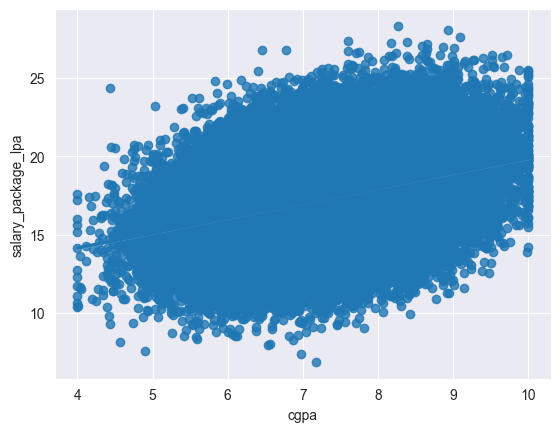

In [240]:
sns.regplot(x="cgpa", y= y_reg, data=df)
plt.show()

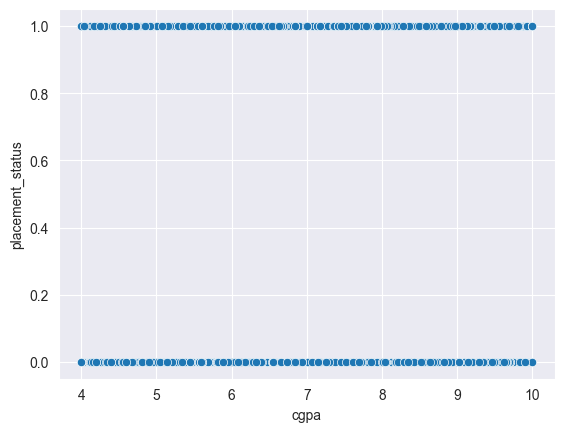

In [241]:
sns.scatterplot(x=df["cgpa"], y= y_cal)
plt.show()

In [243]:
df.corr()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
branch,1.000000,0.001150,-0.001580,0.000006,-0.002858,0.000479,-0.000832,0.004744,-0.004135,-0.001908,-0.000255,0.002272,0.002527,-0.005863,0.000148,-0.003600,-0.001470,-0.006789
college_tier,0.001150,1.000000,-0.233985,0.003982,-0.001498,-0.001532,0.000048,0.000336,0.004777,-0.003005,-0.000177,-0.008472,0.003996,0.001281,-0.001658,-0.001402,-0.180052,-0.356266
cgpa,-0.001580,-0.233985,1.000000,-0.003757,-0.006737,-0.001525,0.000108,-0.000479,-0.004248,0.004056,0.000280,0.002458,-0.002141,0.002199,0.001281,0.000351,0.148932,0.337110
backlogs,0.000006,0.003982,-0.003757,1.000000,-0.002605,0.000614,-0.002761,0.002711,0.003838,-0.004868,-0.001612,0.002540,-0.004352,0.002331,0.002909,-0.000220,-0.058815,0.007919
coding_skills,-0.002858,-0.001498,-0.006737,-0.002605,1.000000,-0.001795,-0.004922,-0.005533,-0.000283,0.002411,0.002321,-0.004415,0.007995,-0.000973,-0.003166,0.001256,0.087657,0.269022
dsa_score,0.000479,-0.001532,-0.001525,0.000614,-0.001795,1.000000,0.002017,-0.003078,-0.001357,0.002268,0.006021,-0.001999,-0.003375,-0.000274,-0.000818,0.000464,0.086594,0.400980
aptitude_score,-0.000832,0.000048,0.000108,-0.002761,-0.004922,0.002017,1.000000,0.004404,0.000561,-0.000208,-0.001831,-0.004235,0.002051,-0.006090,-0.003593,0.002014,0.045146,-0.009342
communication_skills,0.004744,0.000336,-0.000479,0.002711,-0.005533,-0.003078,0.004404,1.000000,-0.001263,0.000370,0.003517,0.001047,-0.002965,0.005999,-0.003068,-0.004540,0.051034,-0.011931
ml_knowledge,-0.004135,0.004777,-0.004248,0.003838,-0.000283,-0.001357,0.000561,-0.001263,1.000000,-0.000209,0.000543,0.000594,0.000277,-0.003932,0.005405,0.003727,0.002097,0.300207
system_design,-0.001908,-0.003005,0.004056,-0.004868,0.002411,0.002268,-0.000208,0.000370,-0.000209,1.000000,0.002331,-0.000719,-0.002820,0.000601,-0.001800,0.001176,-0.001583,0.212229


In [244]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_cal_train, y_cal_test = train_test_split(x, y_cal, test_size=0.2, random_state=42)

from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=10000, class_weight="balanced")
rfe = RFECV(lr)
rfe.fit(x_train, y_cal_train)

print(rfe.support_)
print(rfe.ranking_)

[ True  True  True  True  True  True  True  True  True  True  True  True]
[1 1 1 1 1 1 1 1 1 1 1 1]


In [245]:
dt = DecisionTreeClassifier()
rfecvs = RFECV(dt)
rfecvs.fit(x_train, y_cal_train)

print(rfecvs.support_)
print(rfecvs.ranking_)

[False False False False  True False False False False False False False]
[ 5 10 11  3  1  2 12  9  7  8  6  4]


In [246]:
rf = RandomForestClassifier(max_depth=5)
rfecv2 = RFECV(rf)
rfecv2.fit(x_train, y_cal_train)

print(rfecv2.support_)
print(rfecv2.ranking_)

[False  True  True  True False False  True  True False False False False]
[3 1 1 1 7 5 1 1 2 4 6 8]


In [247]:
selected_features = x.columns[rfecv2.support_]
print(selected_features)

Index(['college_tier', 'backlogs', 'dsa_score', 'internships',
       'projects_count'],
      dtype='object')


In [248]:
print("Optimal number of features:", rfe.n_features_)
print("Selected features:", x_train.columns[rfe.support_])

Optimal number of features: 12
Selected features: Index(['branch', 'college_tier', 'backlogs', 'dsa_score', 'ml_knowledge',
       'system_design', 'internships', 'projects_count', 'certifications',
       'hackathons', 'open_source_contributions', 'extracurriculars'],
      dtype='object')


In [249]:
x2 = df[['college_tier', 'backlogs', 'dsa_score', 'internships',
       'projects_count']]


In [250]:
x2_train, x2_test, y_cal_train, y_cal_test = train_test_split(x2, y_cal, test_size=0.2, random_state=42)

In [251]:
rf.fit(x2_train, y_cal_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [252]:
dt.fit(x2_train, y_cal_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [253]:
lr.fit(x2_train, y_cal_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [254]:
y_pred_lr_cal = lr.predict(x2_test)
y_pred_lr_cal

array([1, 1, 0, ..., 0, 1, 1], shape=(20000,))

In [255]:
y_pred_dt_cal = dt.predict(x2_test)
y_pred_dt_cal

array([1, 1, 0, ..., 0, 1, 1], shape=(20000,))

In [256]:
y_pred_rf_cal = rf.predict(x2_test)
y_pred_rf_cal

array([1, 1, 1, ..., 1, 1, 1], shape=(20000,))

In [257]:
from sklearn.metrics import confusion_matrix
cm1 = confusion_matrix(y_cal_test, y_pred_lr_cal)
cm1

array([[4067, 2268],
       [5700, 7965]])

In [258]:
from sklearn.metrics import confusion_matrix
cm2 = confusion_matrix(y_cal_test, y_pred_dt_cal)
cm2

array([[ 1606,  4729],
       [ 2529, 11136]])

In [259]:
from sklearn.metrics import confusion_matrix
cm3 = confusion_matrix(y_cal_test, y_pred_rf_cal)
cm3

array([[  110,  6225],
       [   66, 13599]])

In [260]:
from sklearn.metrics import accuracy_score
ac1 = accuracy_score(y_cal_test, y_pred_lr_cal)
ac1

0.6016

In [261]:
ac2 = accuracy_score(y_cal_test, y_pred_dt_cal)
ac2

0.6371

In [262]:
ac3 = accuracy_score(y_cal_test, y_pred_rf_cal)
ac3

0.68545

<Axes: ylabel='placement_status'>

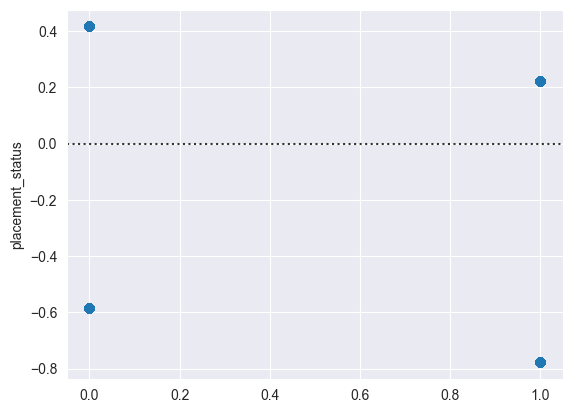

In [263]:
sns.residplot(x=y_pred_lr_cal, y=y_cal_test - y_pred_lr_cal)

In [264]:
lr.fit(x_train, y_cal_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [265]:
y_pred = lr.predict(x_test)
y_pred

array([1, 1, 0, ..., 0, 1, 1], shape=(20000,))

In [266]:
accuracy_score(y_cal_test, y_pred)

0.60725

In [267]:
print(y_cal.value_counts())

placement_status
1    68475
0    31525
Name: count, dtype: int64


In [268]:
from sklearn.metrics import classification_report
print(classification_report(y_cal_test, y_pred_lr_cal))

              precision    recall  f1-score   support

           0       0.42      0.64      0.51      6335
           1       0.78      0.58      0.67     13665

    accuracy                           0.60     20000
   macro avg       0.60      0.61      0.59     20000
weighted avg       0.66      0.60      0.62     20000



In [269]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier()
model.fit(x_train, y_cal_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [215]:
y_gb_pred_cal = model.predict(x_test)
y_gb_pred_cal

array([1, 1, 1, ..., 1, 1, 1], shape=(20000,))

In [216]:
print(classification_report(y_cal_test, y_gb_pred_cal))

              precision    recall  f1-score   support

           0       0.58      0.10      0.17      6335
           1       0.70      0.97      0.81     13665

    accuracy                           0.69     20000
   macro avg       0.64      0.53      0.49     20000
weighted avg       0.66      0.69      0.61     20000



In [271]:
importances = rf.feature_importances_